In [1]:
# Cell 1: GPU Check
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP = torch.cuda.is_available()

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
# Cell 2: Install dependencies
!pip install -q scipy

In [3]:
# Cell 3: Imports
import os, math, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.utils import save_image
from PIL import Image
from scipy.io import loadmat
import matplotlib.pyplot as plt

# torch.cuda.amp APIs deprecated in PyTorch 2.x — use new API
autocast  = lambda enabled=True: torch.amp.autocast('cuda', enabled=enabled)
GradScaler = lambda enabled=True: torch.amp.GradScaler('cuda', enabled=enabled)

os.makedirs('/kaggle/working/checkpoints', exist_ok=True)
os.makedirs('/kaggle/working/checkpoints/phase2', exist_ok=True)
os.makedirs('/kaggle/working/results', exist_ok=True)
os.makedirs('/kaggle/working/results/phase2', exist_ok=True)
print('Directories ready.')

Directories ready.


In [ ]:
# Cell 4: Phase 1 Config

import os

# =========================
# Paths
# =========================

P1_DATA_DIR = "/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba"

P1_CKPT_DIR = "/kaggle/working/checkpoints"
P1_RES_DIR  = "/kaggle/working/results"

os.makedirs(P1_CKPT_DIR, exist_ok=True)
os.makedirs(P1_RES_DIR, exist_ok=True)

# =========================
# Image Settings
# =========================

IMAGE_SIZE = 256
NOISE_STD  = 0.05

# =========================
# Training Settings
# =========================

BATCH_SIZE = 32

NUM_EPOCHS_P1 = 80
WARMUP_EPOCHS = 5

LR = 1e-4

BETA1 = 0.5
BETA2 = 0.999

# =========================
# Loss Weights
# =========================

LAMBDA_L1   = 100.0
LAMBDA_PERC = 10.0
LAMBDA_SSIM = 10.0
LAMBDA_ADV  = 1.0

# =========================
# Dataset Size
# =========================

TRAIN_SIZE = 10000
VAL_SIZE   = 1000



# =========================
# Verify Dataset
# =========================

print("Phase 1 config ready.")
print("Dataset path:", P1_DATA_DIR)
print("Dataset exists:", os.path.exists(P1_DATA_DIR))

if os.path.exists(P1_DATA_DIR):
    print("Images found:", len(os.listdir(P1_DATA_DIR)))

print("Checkpoint dir:", P1_CKPT_DIR)
print("Results dir:", P1_RES_DIR)

In [ ]:
# Show everything in /kaggle/input/
for root, dirs, files in os.walk('/kaggle/input'):
    level = root.replace('/kaggle/input', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 3:
        sub = ' ' * 2 * (level + 1)
        for f in files[:5]:
            print(f'{sub}{f}')

In [ ]:
# Cell 5: CelebA Dataset (with augmentation)
class CelebADataset(Dataset):
    def __init__(self, root_dir, split='train', image_size=256, noise_std=0.05,
                 train_size=200, val_size=40):
        self.noise_std = noise_std
        all_imgs = sorted([
            os.path.join(root_dir, f) for f in os.listdir(root_dir)
            if f.lower().endswith(('.jpg', '.png'))
        ])[:train_size + val_size]
        self.paths = all_imgs[:train_size] if split == 'train' else all_imgs[train_size:]

        # Augmentation only for training
        if split == 'train':
            self.tf = transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
                transforms.ToTensor(),
            ])
        else:
            self.tf = transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.ToTensor(),
            ])

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        clean = self.tf(Image.open(self.paths[idx]).convert('RGB'))
        noisy = torch.clamp(clean + torch.randn_like(clean) * self.noise_std, 0, 1)
        return noisy, clean

train_ds = CelebADataset(P1_DATA_DIR, 'train', IMAGE_SIZE, NOISE_STD, TRAIN_SIZE, VAL_SIZE)
val_ds   = CelebADataset(P1_DATA_DIR, 'val',   IMAGE_SIZE, NOISE_STD, TRAIN_SIZE, VAL_SIZE)
train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')

In [ ]:
# Cell 6: U-Net Generator
class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_bn=True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 4, stride=2, padding=1, bias=not use_bn)]
        if use_bn: layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)
    def forward(self, x): return self.block(x)

class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=False):
        super().__init__()
        layers = [nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1, bias=False),
                  nn.BatchNorm2d(out_ch)]
        if dropout: layers.append(nn.Dropout(0.5))
        layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)
    def forward(self, x, skip): return torch.cat([self.block(x), skip], dim=1)

class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DownBlock(3, 64, use_bn=False)
        self.enc2 = DownBlock(64, 128)
        self.enc3 = DownBlock(128, 256)
        self.enc4 = DownBlock(256, 512)
        self.enc5 = DownBlock(512, 512)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 512, 4, stride=2, padding=1), nn.LeakyReLU(0.2, inplace=True))
        self.dec1 = UpBlock(512, 512, dropout=True)
        self.dec2 = UpBlock(1024, 512, dropout=True)
        self.dec3 = UpBlock(1024, 256, dropout=True)
        self.dec4 = UpBlock(512, 128)
        self.dec5 = UpBlock(256, 64)
        self.out  = nn.Sequential(
            nn.ConvTranspose2d(128, 3, 4, stride=2, padding=1), nn.Sigmoid())

    def forward(self, x):
        e1=self.enc1(x); e2=self.enc2(e1); e3=self.enc3(e2)
        e4=self.enc4(e3); e5=self.enc5(e4); b=self.bottleneck(e5)
        d=self.dec1(b,e5); d=self.dec2(d,e4); d=self.dec3(d,e3)
        d=self.dec4(d,e2); d=self.dec5(d,e1)
        return self.out(d)

print('U-Net Generator defined.')

In [ ]:
# Cell 7: PatchGAN Discriminator (with Spectral Normalization)
from torch.nn.utils import spectral_norm

class PatchGAN(nn.Module):
    def __init__(self):
        super().__init__()
        def blk(ic, oc, s, bn):
            l = [spectral_norm(nn.Conv2d(ic, oc, 4, stride=s, padding=1, bias=not bn))]
            if bn: l.append(nn.BatchNorm2d(oc))
            l.append(nn.LeakyReLU(0.2, inplace=True))
            return l
        self.model = nn.Sequential(
            *blk(6,64,2,False), *blk(64,128,2,True),
            *blk(128,256,2,True), *blk(256,512,1,True),
            spectral_norm(nn.Conv2d(512,1,4,stride=1,padding=1)))
    def forward(self, noisy, tgt):
        return self.model(torch.cat([noisy, tgt], dim=1))

print('PatchGAN Discriminator (Spectral Norm) defined.')

In [ ]:
# Cell 8: Loss Functions (Phase 1)
class PerceptualLoss(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
        self.s1 = nn.Sequential(*list(vgg)[:4])
        self.s2 = nn.Sequential(*list(vgg)[4:9])
        self.s3 = nn.Sequential(*list(vgg)[9:16])
        for p in self.parameters(): p.requires_grad = False
        self.c = nn.L1Loss()
    def forward(self, g, t):
        g1=self.s1(g); t1=self.s1(t)
        g2=self.s2(g1); t2=self.s2(t1)
        g3=self.s3(g2); t3=self.s3(t2)
        return (self.c(g1,t1)+self.c(g2,t2)+self.c(g3,t3))/3

class SSIMLoss(nn.Module):
    def __init__(self, ws=11, sig=1.5):
        super().__init__()
        coords = torch.arange(ws, dtype=torch.float32) - ws//2
        g = torch.exp(-(coords**2)/(2*sig**2)); g = g/g.sum()
        self.register_buffer('w', (g[:,None]*g[None,:]).unsqueeze(0).unsqueeze(0))
        self.ws = ws
    def _ssim(self, x, y):
        C1,C2 = 0.01**2, 0.03**2
        p = self.ws//2
        win = self.w.expand(x.size(1),1,-1,-1)
        mx=F.conv2d(x,win,padding=p,groups=x.size(1))
        my=F.conv2d(y,win,padding=p,groups=x.size(1))
        sx=F.conv2d(x*x,win,padding=p,groups=x.size(1))-mx**2
        sy=F.conv2d(y*y,win,padding=p,groups=x.size(1))-my**2
        sxy=F.conv2d(x*y,win,padding=p,groups=x.size(1))-mx*my
        return ((2*mx*my+C1)*(2*sxy+C2)/((mx**2+my**2+C1)*(sx+sy+C2))).mean()
    def forward(self, g, t): return 1.0 - self._ssim(g, t)

class GANLoss(nn.Module):
    def __init__(self): super().__init__(); self.c = nn.BCEWithLogitsLoss()
    def forward(self, p, real): return self.c(p, torch.ones_like(p) if real else torch.zeros_like(p))

perc_loss = PerceptualLoss().to(DEVICE)
ssim_loss = SSIMLoss().to(DEVICE)
gan_loss  = GANLoss().to(DEVICE)
l1_loss   = nn.L1Loss()
print('Phase 1 losses ready.')

In [ ]:
# Cell 9: Metrics

import math
import torch
import torch.nn.functional as F

def compute_psnr(gen, tgt):

    gen = gen.float().detach()
    tgt = tgt.float().detach()

    mse = F.mse_loss(gen, tgt).item()

    if mse == 0:
        return float('inf')

    return 20 * math.log10(1.0) - 10 * math.log10(mse)


def compute_ssim(x, y, ws=11, sig=1.5):

    x = x.float().detach()
    y = y.float().detach()

    C1 = 0.01 ** 2
    C2 = 0.03 ** 2

    coords = (
        torch.arange(
            ws,
            dtype=torch.float32,
            device=x.device
        ) - ws // 2
    )

    g = torch.exp(-(coords ** 2) / (2 * sig ** 2))
    g = g / g.sum()

    win = (
        g[:, None] * g[None, :]
    ).unsqueeze(0).unsqueeze(0)

    win = win.expand(
        x.size(1),
        1,
        ws,
        ws
    ).contiguous()

    p = ws // 2

    mx = F.conv2d(
        x,
        win,
        padding=p,
        groups=x.size(1)
    )

    my = F.conv2d(
        y,
        win,
        padding=p,
        groups=y.size(1)
    )

    sx = (
        F.conv2d(
            x * x,
            win,
            padding=p,
            groups=x.size(1)
        )
        - mx ** 2
    )

    sy = (
        F.conv2d(
            y * y,
            win,
            padding=p,
            groups=y.size(1)
        )
        - my ** 2
    )

    sxy = (
        F.conv2d(
            x * y,
            win,
            padding=p,
            groups=x.size(1)
        )
        - mx * my
    )

    ssim_map = (
        (2 * mx * my + C1)
        * (2 * sxy + C2)
    ) / (
        (mx ** 2 + my ** 2 + C1)
        * (sx + sy + C2)
    )

    return ssim_map.mean().item()


print("Metrics ready.")

In [ ]:
# Cell 10: Phase 1 Training (Fixed AMP + SSIM)

import os
import time

os.makedirs(P1_CKPT_DIR, exist_ok=True)
os.makedirs(P1_RES_DIR, exist_ok=True)

G1 = UNetGenerator().to(DEVICE)
D1 = PatchGAN().to(DEVICE)

opt_g1 = optim.Adam(
    G1.parameters(),
    lr=LR,
    betas=(BETA1, BETA2)
)

opt_d1 = optim.Adam(
    D1.parameters(),
    lr=LR,
    betas=(BETA1, BETA2)
)

scheduler_g1 = optim.lr_scheduler.CosineAnnealingLR(
    opt_g1,
    T_max=NUM_EPOCHS_P1,
    eta_min=1e-6
)

scheduler_d1 = optim.lr_scheduler.CosineAnnealingLR(
    opt_d1,
    T_max=NUM_EPOCHS_P1,
    eta_min=1e-6
)

scaler_g1 = GradScaler(enabled=AMP)
scaler_d1 = GradScaler(enabled=AMP)

best_psnr = 0.0

p1_history = {
    'g_loss': [],
    'd_loss': [],
    'psnr': [],
    'ssim': []
}

for epoch in range(1, NUM_EPOCHS_P1 + 1):

    G1.train()
    D1.train()

    warmup = epoch <= WARMUP_EPOCHS

    g_tot = 0.0
    d_tot = 0.0

    t0 = time.time()

    for noisy, clean in train_loader:

        noisy = noisy.to(DEVICE)
        clean = clean.to(DEVICE)

        # -------------------------
        # Discriminator
        # -------------------------

        if not warmup:

            opt_d1.zero_grad()

            with autocast(enabled=AMP):

                fake = G1(noisy).detach()

                ld = 0.5 * (
                    gan_loss(
                        D1(noisy, clean),
                        True
                    )
                    +
                    gan_loss(
                        D1(noisy, fake),
                        False
                    )
                )

            scaler_d1.scale(ld).backward()
            scaler_d1.step(opt_d1)
            scaler_d1.update()

            d_tot += ld.item()

        # -------------------------
        # Generator
        # -------------------------

        opt_g1.zero_grad()

        with autocast(enabled=AMP):

            fake = G1(noisy)

            lg = (
                LAMBDA_L1 *
                l1_loss(fake, clean)
            )

            if not warmup:

                lg += (
                    LAMBDA_PERC *
                    perc_loss(fake, clean)
                )

                lg += (
                    LAMBDA_SSIM *
                    ssim_loss(fake, clean)
                )

                lg += (
                    LAMBDA_ADV *
                    gan_loss(
                        D1(noisy, fake),
                        True
                    )
                )

        scaler_g1.scale(lg).backward()
        scaler_g1.step(opt_g1)
        scaler_g1.update()

        g_tot += lg.item()

    scheduler_g1.step()
    scheduler_d1.step()

    g_avg = g_tot / len(train_loader)

    if warmup:
        d_avg = 0.0
    else:
        d_avg = d_tot / len(train_loader)

    # -------------------------
    # Validation
    # -------------------------

    G1.eval()

    vp = 0.0
    vs = 0.0

    with torch.no_grad():

        for i, (noisy, clean) in enumerate(val_loader):

            noisy = noisy.to(DEVICE)
            clean = clean.to(DEVICE)

            with autocast(enabled=AMP):
                gen = G1(noisy)

            gen_f = gen.float()
            clean_f = clean.float()

            vp += compute_psnr(
                gen_f,
                clean_f
            )

            vs += compute_ssim(
                gen_f,
                clean_f
            )

            if i == 0 and epoch % 10 == 0:

                save_image(
                    torch.cat(
                        [
                            noisy[:4],
                            gen[:4],
                            clean[:4]
                        ],
                        dim=0
                    ),
                    f"{P1_RES_DIR}/epoch_{epoch:03d}.png",
                    nrow=4
                )

    vp /= len(val_loader)
    vs /= len(val_loader)

    cur_lr = scheduler_g1.get_last_lr()[0]

    mode = (
        "WARMUP"
        if warmup
        else "FULL "
    )

    print(
        f"[{mode}] "
        f"Ep {epoch:03d}/{NUM_EPOCHS_P1} | "
        f"G={g_avg:.3f} "
        f"D={d_avg:.3f} | "
        f"PSNR={vp:.2f} "
        f"SSIM={vs:.4f} | "
        f"LR={cur_lr:.2e} | "
        f"{time.time()-t0:.1f}s"
    )

    p1_history['g_loss'].append(g_avg)
    p1_history['d_loss'].append(d_avg)
    p1_history['psnr'].append(vp)
    p1_history['ssim'].append(vs)

    if vp > best_psnr:

        best_psnr = vp

        torch.save(
            {
                'epoch': epoch,
                'generator': G1.state_dict(),
                'discriminator': D1.state_dict(),
                'best_psnr': best_psnr
            },
            f"{P1_CKPT_DIR}/best_model.pth"
        )

print(
    f"\nPhase 1 Done. "
    f"Best PSNR: {best_psnr:.2f} dB"
)

In [ ]:
# Cell 11.1: Phase 1 Results Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs = range(1, NUM_EPOCHS_P1+1)
axes[0].plot(epochs, p1_history['g_loss'], label='G Loss')
axes[0].plot(epochs, p1_history['d_loss'], label='D Loss')
axes[0].set_title('Training Loss'); axes[0].legend()
axes[1].plot(epochs, p1_history['psnr'])
axes[1].set_title('Validation PSNR (dB)')
axes[2].plot(epochs, p1_history['ssim'])
axes[2].set_title('Validation SSIM')
plt.tight_layout(); plt.savefig(f'{P1_RES_DIR}/training_curves.png'); plt.show()

G1.eval()
noisy_sample, clean_sample = next(iter(val_loader))
noisy_sample = noisy_sample[:6].to(DEVICE)
with torch.no_grad():
    with torch.amp.autocast('cuda', enabled=AMP):
        gen_sample = G1(noisy_sample)

# float32 convert — AMP float16 দেয়, matplotlib সেটা support করে না
noisy_np = noisy_sample.cpu().float()
gen_np   = gen_sample.cpu().float()
clean_np = clean_sample.float()

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for i in range(6):
    axes[0,i].imshow(noisy_np[i].permute(1,2,0).clamp(0,1).numpy())
    axes[0,i].set_title('Noisy'); axes[0,i].axis('off')
    axes[1,i].imshow(gen_np[i].permute(1,2,0).clamp(0,1).numpy())
    axes[1,i].set_title('Denoised'); axes[1,i].axis('off')
    axes[2,i].imshow(clean_np[i].permute(1,2,0).clamp(0,1).numpy())
    axes[2,i].set_title('Ground Truth'); axes[2,i].axis('off')
plt.suptitle('Phase 1: Noisy → Denoised → Ground Truth')
plt.tight_layout(); plt.savefig(f'{P1_RES_DIR}/sample_results.png'); plt.show()
print(f'Final PSNR: {p1_history["psnr"][-1]:.2f} dB | SSIM: {p1_history["ssim"][-1]:.4f}')

In [4]:
# Cell 12: Phase 2 Config
P2_DATA_DIR  = '/kaggle/input/datasets/maulidio16/300w-lp/300W_LP'
P2_CKPT_DIR  = '/kaggle/working/checkpoints/phase2'
P2_RES_DIR   = '/kaggle/working/results/phase2'

# ── FULL TRAINING RUN ────────────────────────────────────────────
MAX_IDENTITIES = None   # None = scan entire dataset (no early stop)
MAX_PAIRS      = None   # None = use all drawable pairs per epoch
NUM_WORKERS_P2 = 4
# ──────────────────────────────────────────────────────────────────

IMAGE_SIZE_P2    = 256
NUM_POSE_CLASSES = 5
POSE_ANGLES      = [-90, -45, 0, 45, 90]
POSE_DIM         = 256
BATCH_SIZE_P2    = 4
NUM_EPOCHS_P2    = 40
LR_P2            = 2e-4
GRAD_CLIP        = 1.0    # gradient clipping norm — stabilises GAN training

# Loss weights
LAMBDA_ADV_P2  = 1.0
LAMBDA_PAIRED  = 20.0   # L1 vs. ground-truth target image (requires paired data)
LAMBDA_PERC_P2 = 5.0    # perceptual vs. ground-truth target
LAMBDA_CYCLE   = 10.0   # G(G(src, tgt_pose), src_pose) ≈ src
LAMBDA_POSE    = 10.0   # discriminator pose-classification head (was 5.0 — doubled)

print('Phase 2 config ready (FULL TRAINING RUN).')

Phase 2 config ready (FULL TRAINING RUN).


In [5]:
# Cell 13: Paired 300W-LP Dataset
#
# 300W-LP is synthetic: the same base face is rendered at multiple yaw angles.
# Filename pattern: {SUBSET}_{ID}_{CROP}_{AUGIDX}.jpg
# We strip the trailing _N suffix to build an identity key, then return
# (src_img, tgt_img) pairs from the same identity at different pose classes.
#
# Images are normalised to [-1, 1] (standard GAN convention) to match the
# Tanh output of the generator.

def yaw_to_class(yaw_deg):
    return int(np.argmin([abs(yaw_deg - a) for a in POSE_ANGLES]))

def to_onehot(cls, n=NUM_POSE_CLASSES):
    v = torch.zeros(n, dtype=torch.float32)
    v[cls] = 1.0
    return v

def get_base_id(img_path):
    """dir/AFW_134212_1_0.jpg  ->  dir/AFW_134212_1  (strips trailing _angle)."""
    fname  = os.path.splitext(os.path.basename(img_path))[0]
    prefix = fname.rsplit('_', 1)[0]
    return os.path.join(os.path.dirname(img_path), prefix)


class PairedPoseDataset(Dataset):
    def __init__(self, root_dir, split='train', image_size=128, min_pose_classes=2,
                 max_identities=None):
        identity_map = {}   # base_id -> {pose_class: [img_path, ...]}

        scan_done = False
        for subset in sorted(os.listdir(root_dir)):
            if scan_done:
                break
            subset_dir = os.path.join(root_dir, subset)
            if not os.path.isdir(subset_dir):
                continue
            for fname in os.listdir(subset_dir):
                if not fname.lower().endswith('.jpg'):
                    continue
                img_path = os.path.join(subset_dir, fname)
                mat_path = img_path.replace('.jpg', '.mat')
                if not os.path.exists(mat_path):
                    continue
                try:
                    mat = loadmat(mat_path)
                    if 'Pose_Para' not in mat:
                        continue
                    yaw = float(mat['Pose_Para'][0][1]) * (180.0 / np.pi)
                    cls = yaw_to_class(yaw)
                    key = get_base_id(img_path)
                    if key not in identity_map:
                        identity_map[key] = {}
                    identity_map[key].setdefault(cls, []).append(img_path)
                except Exception:
                    continue

                if max_identities is not None:
                    valid_count = sum(1 for v in identity_map.values()
                                       if len(v) >= min_pose_classes)
                    if valid_count >= max_identities:
                        scan_done = True
                        break

        # Histogram of images per pose class
        class_hist = {c: 0 for c in range(NUM_POSE_CLASSES)}
        for v in identity_map.values():
            for c, imgs in v.items():
                class_hist[c] += len(imgs)
        print(f'[{split}] pose class histogram (angle: image count): ' +
              ', '.join(f'{POSE_ANGLES[c]}°: {class_hist[c]}' for c in range(NUM_POSE_CLASSES)))

        valid = {k: v for k, v in identity_map.items()
                 if len(v) >= min_pose_classes}

        all_ids = sorted(valid.keys())
        random.shuffle(all_ids)
        n_train  = int(len(all_ids) * 0.90)
        split_ids = all_ids[:n_train] if split == 'train' else all_ids[n_train:]

        self.data     = {k: valid[k] for k in split_ids}
        self.id_list  = split_ids
        # Normalise to [-1, 1] — matches Tanh generator output
        self.tf = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])
        print(f'[{split}] identities: {len(self.id_list)} '
              f'| total pairs drawable: ~{len(self.id_list) * 4}')

    def __len__(self):
        n = len(self.id_list)
        if MAX_PAIRS is not None:
            n = min(n, MAX_PAIRS)
        return n

    def __getitem__(self, idx):
        key     = self.id_list[idx]
        by_cls  = self.data[key]
        classes = list(by_cls.keys())

        src_cls = random.choice(classes)
        tgt_cls = random.choice([c for c in classes if c != src_cls])

        src_img = self.tf(Image.open(random.choice(by_cls[src_cls])).convert('RGB'))
        tgt_img = self.tf(Image.open(random.choice(by_cls[tgt_cls])).convert('RGB'))

        return (src_img, tgt_img,
                to_onehot(src_cls), to_onehot(tgt_cls),
                src_cls, tgt_cls)


p2_train_ds = PairedPoseDataset(P2_DATA_DIR, 'train', IMAGE_SIZE_P2, max_identities=MAX_IDENTITIES)
p2_val_ds   = PairedPoseDataset(P2_DATA_DIR, 'val',   IMAGE_SIZE_P2, max_identities=MAX_IDENTITIES)
p2_train_loader = DataLoader(p2_train_ds, BATCH_SIZE_P2,
                              shuffle=True,  num_workers=NUM_WORKERS_P2, pin_memory=True, drop_last=True)
p2_val_loader   = DataLoader(p2_val_ds,   BATCH_SIZE_P2,
                              shuffle=False, num_workers=NUM_WORKERS_P2, pin_memory=True)
print(f'Loaders ready.')

[train] pose class histogram (angle: image count): -90°: 17084, -45°: 33793, 0°: 20669, 45°: 33794, 90°: 17110
[train] identities: 6906 | total pairs drawable: ~27624
[val] pose class histogram (angle: image count): -90°: 17084, -45°: 33793, 0°: 20669, 45°: 33794, 90°: 17110
[val] identities: 768 | total pairs drawable: ~3072
Loaders ready.


In [6]:
# Cell 14: Multi-Angle Generator v2 — ResNet encoder + AdaIN decoder
#
# Key design decisions:
#   • NO skip connections: they create a direct spatial pathway that lets
#     the network reconstruct the source without using pose.
#   • AdaIN at every bottleneck residual block: pose code controls feature
#     statistics at every level (same mechanism as StyleGAN).
#   • Instance normalization in encoder/decoder — more stable for low-batch.
#   • Tanh output to match [-1, 1] normalised inputs.
#   • AdaIN fc initialised near-zero so it starts as identity and learns
#     to modulate gradually — prevents large gamma/beta blowing up early.

class AdaIN(nn.Module):
    """Adaptive Instance Normalization — injects pose into each residual block."""
    def __init__(self, num_features, pose_dim):
        super().__init__()
        self.norm = nn.InstanceNorm2d(num_features, affine=False)
        self.fc   = nn.Linear(pose_dim, num_features * 2)
        # Start near identity: small gamma perturbation, zero beta shift
        nn.init.normal_(self.fc.weight, 0, 0.02)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x, pose_code):
        params = self.fc(pose_code).unsqueeze(-1).unsqueeze(-1)
        gamma, beta = params.chunk(2, dim=1)
        return (1.0 + gamma) * self.norm(x) + beta


class ResBlockAdaIN(nn.Module):
    def __init__(self, ch, pose_dim):
        super().__init__()
        self.conv1  = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.conv2  = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.adain1 = AdaIN(ch, pose_dim)
        self.adain2 = AdaIN(ch, pose_dim)

    def forward(self, x, pose_code):
        h = F.relu(self.adain1(self.conv1(x),  pose_code), inplace=True)
        h =         self.adain2(self.conv2(h),  pose_code)
        return F.relu(x + h, inplace=True)


class MultiAngleGeneratorV2(nn.Module):
    def __init__(self, num_poses=5, pose_dim=256, n_res=6, base_ch=64):
        super().__init__()

        # Dense pose embedding: one-hot(5) → pose_dim
        self.pose_enc = nn.Sequential(
            nn.Linear(num_poses, 128), nn.ReLU(inplace=True),
            nn.Linear(128, pose_dim),  nn.ReLU(inplace=True),
        )

        # Image encoder — 3 stride-2 downsamples
        self.enc = nn.Sequential(
            nn.Conv2d(3, base_ch, 7, padding=3, bias=False),
            nn.InstanceNorm2d(base_ch), nn.ReLU(inplace=True),

            nn.Conv2d(base_ch,   base_ch*2, 4, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(base_ch*2), nn.ReLU(inplace=True),

            nn.Conv2d(base_ch*2, base_ch*4, 4, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(base_ch*4), nn.ReLU(inplace=True),

            nn.Conv2d(base_ch*4, base_ch*8, 4, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(base_ch*8), nn.ReLU(inplace=True),
        )

        # Bottleneck: n_res residual blocks, each conditioned on pose via AdaIN
        self.res = nn.ModuleList(
            [ResBlockAdaIN(base_ch*8, pose_dim) for _ in range(n_res)]
        )

        # Decoder — no skip connections; Tanh to match [-1, 1] input range
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(base_ch*8, base_ch*4, 4, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(base_ch*4), nn.ReLU(inplace=True),

            nn.ConvTranspose2d(base_ch*4, base_ch*2, 4, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(base_ch*2), nn.ReLU(inplace=True),

            nn.ConvTranspose2d(base_ch*2, base_ch,   4, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(base_ch),   nn.ReLU(inplace=True),

            nn.Conv2d(base_ch, 3, 7, padding=3),
            nn.Tanh(),   # output in [-1, 1] to match normalised inputs
        )

    def forward(self, x, pose):
        code = self.pose_enc(pose)
        feat = self.enc(x)
        for blk in self.res:
            feat = blk(feat, code)
        return self.dec(feat)


print('MultiAngleGeneratorV2 (ResNet + AdaIN, Tanh output, near-zero AdaIN init) defined.')

MultiAngleGeneratorV2 (ResNet + AdaIN, Tanh output, near-zero AdaIN init) defined.


In [7]:
# Cell 15: Pose Discriminator (PatchGAN + pose-classification head)
# Real pair: (src, ground-truth-tgt) where tgt is the actual rendered view.
# Fake pair: (src, G(src, tgt_pose)).
# The pose head classifies WHICH pose the target image is at,
# giving the generator a direct gradient signal toward the correct viewpoint.

from torch.nn.utils import spectral_norm

class PoseDiscriminator(nn.Module):
    def __init__(self, num_poses=5):
        super().__init__()
        def blk(ic, oc, s, bn):
            layers = [spectral_norm(nn.Conv2d(ic, oc, 4, stride=s, padding=1, bias=not bn))]
            if bn: layers.append(nn.InstanceNorm2d(oc))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.shared = nn.Sequential(
            *blk(6, 64,  2, False),
            *blk(64, 128, 2, True),
            *blk(128, 256, 2, True),
            *blk(256, 512, 1, True),
        )
        self.patch_head = spectral_norm(nn.Conv2d(512, 1, 4, stride=1, padding=1))
        self.pose_head  = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(512, 128), nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, num_poses),
        )

    def forward(self, src, tgt):
        x = self.shared(torch.cat([src, tgt], dim=1))
        return self.patch_head(x), self.pose_head(x)

print('PoseDiscriminator defined.')

PoseDiscriminator defined.


In [8]:
# Cell 16: Phase 2 Loss Functions
# Self-contained: does not rely on Phase 1 cells having been run.
if 'PerceptualLoss' not in globals():
    class PerceptualLoss(nn.Module):
        def __init__(self):
            super().__init__()
            vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT).features
            self.s1 = nn.Sequential(*list(vgg)[:4])
            self.s2 = nn.Sequential(*list(vgg)[4:9])
            self.s3 = nn.Sequential(*list(vgg)[9:16])
            for p in self.parameters(): p.requires_grad = False
            self.c = nn.L1Loss()
        def forward(self, g, t):
            g1=self.s1(g); t1=self.s1(t)
            g2=self.s2(g1); t2=self.s2(t1)
            g3=self.s3(g2); t3=self.s3(t2)
            return (self.c(g1,t1)+self.c(g2,t2)+self.c(g3,t3))/3

if 'perc_loss' not in globals():
    perc_loss = PerceptualLoss().to(DEVICE)
if 'l1_loss' not in globals():
    l1_loss = nn.L1Loss()
pose_ce_loss = nn.CrossEntropyLoss()
bce_loss     = nn.BCEWithLogitsLoss()
print('Phase 2 losses ready.')

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 198MB/s]  


Phase 2 losses ready.


In [9]:
# Cell 17: Phase 2 Training
#
# Changes vs. previous version:
#   1. CosineAnnealingLR for both G and D — smooth decay 2e-4 → 1e-6.
#   2. Gradient clipping (GRAD_CLIP=1.0) before every optimizer step.
#   3. save_image uses normalize=True, value_range=(-1,1) for Tanh outputs.

G2 = MultiAngleGeneratorV2(
    num_poses=NUM_POSE_CLASSES, pose_dim=POSE_DIM).to(DEVICE)
D2 = PoseDiscriminator(num_poses=NUM_POSE_CLASSES).to(DEVICE)

opt_g2    = optim.Adam(G2.parameters(), lr=LR_P2, betas=(0.5, 0.999))
opt_d2    = optim.Adam(D2.parameters(), lr=LR_P2, betas=(0.5, 0.999))
scaler_g2 = GradScaler(enabled=AMP)
scaler_d2 = GradScaler(enabled=AMP)

scheduler_g2 = optim.lr_scheduler.CosineAnnealingLR(opt_g2, T_max=NUM_EPOCHS_P2, eta_min=1e-6)
scheduler_d2 = optim.lr_scheduler.CosineAnnealingLR(opt_d2, T_max=NUM_EPOCHS_P2, eta_min=1e-6)

best_g2_loss = float('inf')
p2_history   = {'g_loss': [], 'd_loss': []}

for epoch in range(1, NUM_EPOCHS_P2 + 1):
    G2.train(); D2.train()
    g_tot = d_tot = 0.0
    t0 = time.time()

    for src, tgt, src_pose, tgt_pose, src_cls, tgt_cls in p2_train_loader:
        src      = src.to(DEVICE)
        tgt      = tgt.to(DEVICE)
        src_pose = src_pose.to(DEVICE)
        tgt_pose = tgt_pose.to(DEVICE)
        src_cls  = src_cls.to(DEVICE)
        tgt_cls  = tgt_cls.to(DEVICE)

        # ── Discriminator ──────────────────────────────────────────────────
        opt_d2.zero_grad()
        with torch.amp.autocast('cuda', enabled=AMP):
            fake    = G2(src, tgt_pose).detach()
            rp, rpl = D2(src, tgt)
            fp, fpl = D2(src, fake)
            ld = (0.5 * (bce_loss(rp, torch.ones_like(rp)) +
                         bce_loss(fp, torch.zeros_like(fp)))
                  + LAMBDA_POSE * pose_ce_loss(rpl, tgt_cls)
                  + LAMBDA_POSE * pose_ce_loss(fpl, tgt_cls))
        scaler_d2.scale(ld).backward()
        scaler_d2.unscale_(opt_d2)
        torch.nn.utils.clip_grad_norm_(D2.parameters(), GRAD_CLIP)
        scaler_d2.step(opt_d2); scaler_d2.update()
        d_tot += ld.item()

        # ── Generator ──────────────────────────────────────────────────────
        opt_g2.zero_grad()
        with torch.amp.autocast('cuda', enabled=AMP):
            fake   = G2(src, tgt_pose)
            cycled = G2(fake, src_pose)
            fp, fpl = D2(src, fake)

            lg  = LAMBDA_ADV_P2  * bce_loss(fp, torch.ones_like(fp))
            lg += LAMBDA_PAIRED  * l1_loss(fake, tgt)
            lg += LAMBDA_PERC_P2 * perc_loss(fake.float(), tgt.float())
            lg += LAMBDA_CYCLE   * l1_loss(cycled, src)
            lg += LAMBDA_POSE    * pose_ce_loss(fpl, tgt_cls)

        scaler_g2.scale(lg).backward()
        scaler_g2.unscale_(opt_g2)
        torch.nn.utils.clip_grad_norm_(G2.parameters(), GRAD_CLIP)
        scaler_g2.step(opt_g2); scaler_g2.update()
        g_tot += lg.item()

    scheduler_g2.step()
    scheduler_d2.step()

    n = len(p2_train_loader)
    g_avg = g_tot / n
    d_avg = d_tot / n
    p2_history['g_loss'].append(g_avg)
    p2_history['d_loss'].append(d_avg)
    cur_lr = scheduler_g2.get_last_lr()[0]
    print(f'Ep {epoch:03d}/{NUM_EPOCHS_P2} | G={g_avg:.3f} D={d_avg:.3f} | '
          f'LR={cur_lr:.2e} | {time.time()-t0:.1f}s')

    if g_avg < best_g2_loss:
        best_g2_loss = g_avg
        torch.save({'epoch': epoch, 'generator': G2.state_dict(),
                    'discriminator': D2.state_dict()},
                   f'{P2_CKPT_DIR}/best_model_phase2.pth')

    if epoch % 10 == 0 or epoch == NUM_EPOCHS_P2:
        G2.eval()
        batch      = next(iter(p2_val_loader))
        sample_src = batch[0][:4].to(DEVICE)
        sample_tgt = batch[1][:4]
        all_views  = [sample_src.float(), sample_tgt.float().to(DEVICE)]
        with torch.no_grad():
            for ai in range(NUM_POSE_CLASSES):
                p = torch.zeros(4, NUM_POSE_CLASSES).to(DEVICE)
                p[:, ai] = 1.0
                with torch.amp.autocast('cuda', enabled=AMP):
                    gen = G2(sample_src, p)
                all_views.append(gen.float())
        os.makedirs(f'{P2_RES_DIR}/epoch_{epoch:03d}', exist_ok=True)
        # normalize=True with value_range=(-1,1) maps Tanh output to [0,1] for saving
        save_image(torch.cat(all_views, 0),
                   f'{P2_RES_DIR}/epoch_{epoch:03d}/multiangle.png',
                   nrow=4, normalize=True, value_range=(-1, 1))
        G2.train()

print(f'\nPhase 2 Done. Best G loss: {best_g2_loss:.4f}')

Ep 001/40 | G=18.056 D=22.053 | LR=2.00e-04 | 544.8s
Ep 002/40 | G=10.323 D=12.592 | LR=1.99e-04 | 545.8s
Ep 003/40 | G=8.906 D=9.682 | LR=1.97e-04 | 544.7s
Ep 004/40 | G=8.045 D=7.981 | LR=1.95e-04 | 541.1s
Ep 005/40 | G=7.527 D=6.992 | LR=1.92e-04 | 542.3s
Ep 006/40 | G=7.181 D=6.258 | LR=1.89e-04 | 543.8s
Ep 007/40 | G=6.939 D=5.699 | LR=1.85e-04 | 543.7s
Ep 008/40 | G=6.730 D=5.384 | LR=1.81e-04 | 543.5s
Ep 009/40 | G=6.569 D=5.325 | LR=1.76e-04 | 542.3s
Ep 010/40 | G=6.467 D=4.949 | LR=1.71e-04 | 541.9s
Ep 011/40 | G=6.350 D=4.914 | LR=1.65e-04 | 541.9s
Ep 012/40 | G=6.301 D=4.676 | LR=1.59e-04 | 542.3s
Ep 013/40 | G=6.229 D=4.670 | LR=1.52e-04 | 541.9s
Ep 014/40 | G=6.144 D=4.625 | LR=1.46e-04 | 541.4s
Ep 015/40 | G=6.097 D=4.532 | LR=1.39e-04 | 541.3s
Ep 016/40 | G=6.031 D=4.292 | LR=1.31e-04 | 539.3s
Ep 017/40 | G=5.994 D=4.325 | LR=1.24e-04 | 542.1s
Ep 018/40 | G=5.936 D=4.030 | LR=1.16e-04 | 540.7s
Ep 019/40 | G=5.925 D=4.047 | LR=1.08e-04 | 540.0s
Ep 020/40 | G=5.857 D=3.717

In [10]:
# DIAGNOSTIC: pose_enc / AdaIN collapse check
#
# Goal: confirm whether some pose classes (-90/-45/0) collapse to the same
# (or near-zero) embedding due to dead ReLUs in pose_enc, which would make
# AdaIN's gamma/beta identical for those classes -> near-identical outputs.

G2.eval()
with torch.no_grad():
    onehots = torch.eye(NUM_POSE_CLASSES).to(DEVICE)   # one row per pose class
    codes = G2.pose_enc(onehots)                        # [5, POSE_DIM]

    print('pose_enc embeddings (one-hot -> code):')
    for i, angle in enumerate(POSE_ANGLES):
        c = codes[i]
        print(f'  {angle:>4}° | norm={c.norm().item():8.4f} | '
              f'nonzero={int((c != 0).sum().item())}/{c.numel()} | '
              f'mean={c.mean().item():.4f}')

    print('\nPairwise embedding distances (||code_i - code_j||):')
    header = '        ' + ''.join(f'{a:>8}°' for a in POSE_ANGLES)
    print(header)
    for i, ai in enumerate(POSE_ANGLES):
        row = f'  {ai:>4}° | '
        for j in range(NUM_POSE_CLASSES):
            d = (codes[i] - codes[j]).norm().item()
            row += f'{d:8.4f} '
        print(row)

    # AdaIN gamma/beta from the first residual block, for direct comparison
    adain = G2.res[0].adain1
    params = adain.fc(codes)              # [5, 2*ch]
    gamma, beta = params.chunk(2, dim=1)
    print('\nResBlock[0].adain1 gamma/beta (one row per pose class):')
    for i, angle in enumerate(POSE_ANGLES):
        print(f'  {angle:>4}° | gamma_norm={gamma[i].norm().item():8.4f} | '
              f'beta_norm={beta[i].norm().item():8.4f}')

pose_enc embeddings (one-hot -> code):
   -90° | norm=  2.7706 | nonzero=115/256 | mean=0.0988
   -45° | norm=  2.6757 | nonzero=134/256 | mean=0.0992
     0° | norm=  2.7138 | nonzero=146/256 | mean=0.1048
    45° | norm=  2.6557 | nonzero=131/256 | mean=0.1000
    90° | norm=  2.8536 | nonzero=109/256 | mean=0.0991

Pairwise embedding distances (||code_i - code_j||):
             -90°     -45°       0°      45°      90°
   -90° |   0.0000   1.4755   1.7240   1.7360   1.5862 
   -45° |   1.4755   0.0000   1.3502   1.4805   1.7294 
     0° |   1.7240   1.3502   0.0000   1.4096   1.8227 
    45° |   1.7360   1.4805   1.4096   0.0000   1.4796 
    90° |   1.5862   1.7294   1.8227   1.4796   0.0000 

ResBlock[0].adain1 gamma/beta (one row per pose class):
   -90° | gamma_norm= 11.7194 | beta_norm= 27.5246
   -45° | gamma_norm= 11.8942 | beta_norm= 26.7574
     0° | gamma_norm= 12.5982 | beta_norm= 26.9437
    45° | gamma_norm= 12.0332 | beta_norm= 27.0593
    90° | gamma_norm= 11.7678 | b

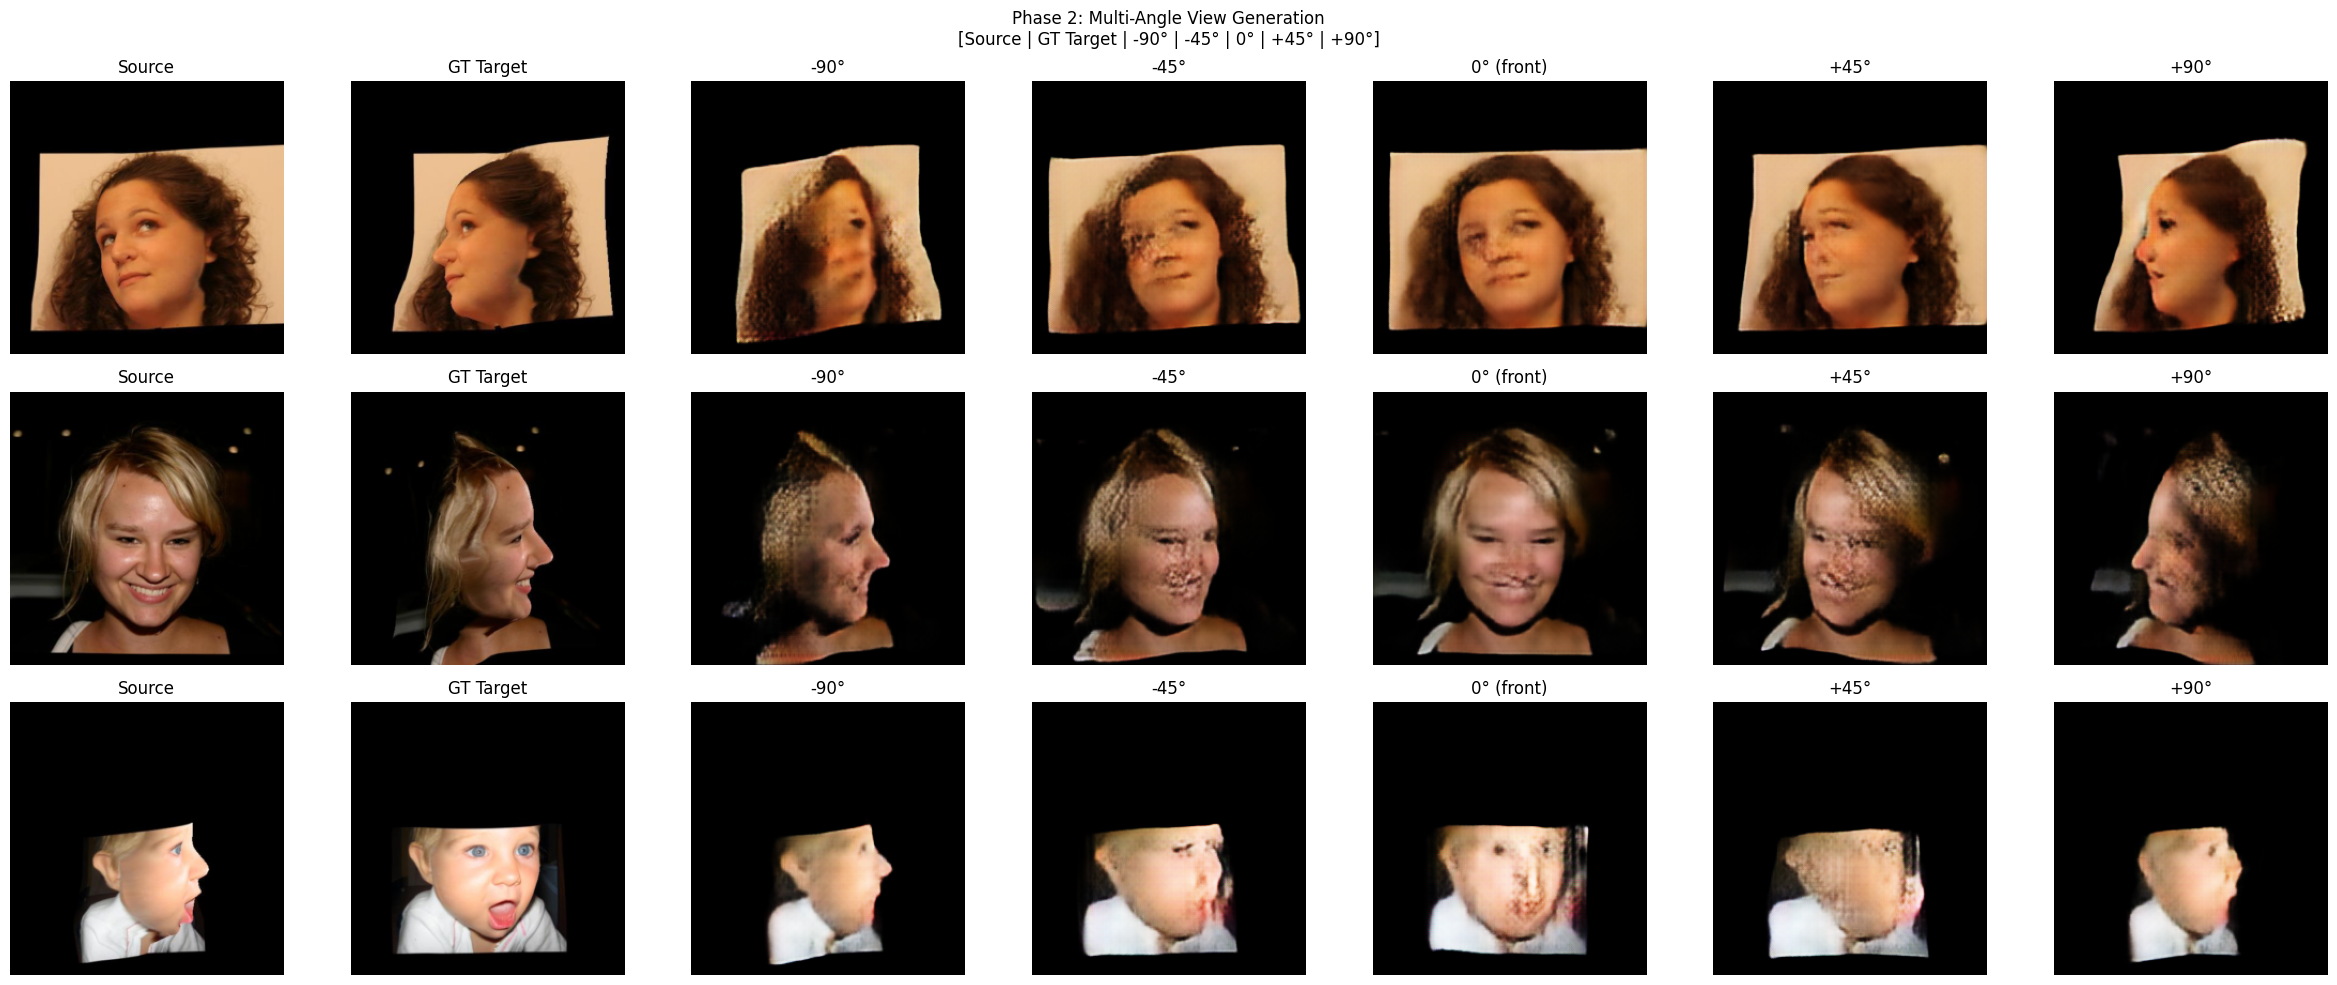

Multi-angle results saved!


In [11]:
# Cell 18: Phase 2 Multi-Angle Visualization
# denorm converts [-1, 1] Tanh output back to [0, 1] for display.
def denorm(t):
    return (t.float() * 0.5 + 0.5).clamp(0, 1)

G2.eval()
batch      = next(iter(p2_val_loader))
sample_src = batch[0][:3].to(DEVICE)
sample_tgt = batch[1][:3]
ANGLE_LABELS = ['-90°', '-45°', '0° (front)', '+45°', '+90°']

fig, axes = plt.subplots(3, 7, figsize=(24, 10))

with torch.no_grad():
    for row in range(3):
        axes[row, 0].imshow(denorm(sample_src[row].cpu()).permute(1,2,0).numpy())
        axes[row, 0].set_title('Source'); axes[row, 0].axis('off')

        axes[row, 1].imshow(denorm(sample_tgt[row]).permute(1,2,0).numpy())
        axes[row, 1].set_title('GT Target'); axes[row, 1].axis('off')

        for ai in range(NUM_POSE_CLASSES):
            p = torch.zeros(1, NUM_POSE_CLASSES).to(DEVICE)
            p[0, ai] = 1.0
            with torch.amp.autocast('cuda', enabled=AMP):
                gen = G2(sample_src[row:row+1], p)
            axes[row, ai+2].imshow(denorm(gen[0].cpu()).permute(1,2,0).numpy())
            axes[row, ai+2].set_title(ANGLE_LABELS[ai])
            axes[row, ai+2].axis('off')

plt.suptitle('Phase 2: Multi-Angle View Generation\n'
             '[Source | GT Target | -90° | -45° | 0° | +45° | +90°]')
plt.tight_layout()
plt.savefig(f'{P2_RES_DIR}/multiangle_final.png', dpi=150)
plt.show()
print('Multi-angle results saved!')

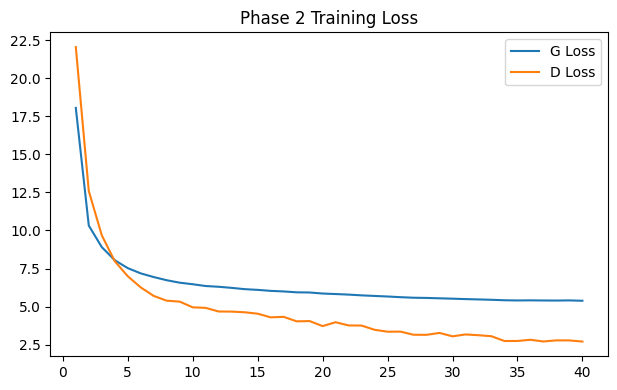

In [12]:
# Cell 19: Training Curves (Phase 2)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ep2 = range(1, NUM_EPOCHS_P2+1)
axes[0].plot(ep2, p2_history['g_loss'], label='G Loss')
axes[0].plot(ep2, p2_history['d_loss'], label='D Loss')
axes[0].set_title('Phase 2 Training Loss'); axes[0].legend()
axes[1].set_visible(False)
plt.tight_layout(); plt.savefig(f'{P2_RES_DIR}/p2_curves.png'); plt.show()

In [13]:
# Cell 20: Download Trained Models
from IPython.display import FileLink
import shutil

# Zip both checkpoints
shutil.make_archive('/kaggle/working/models', 'zip', '/kaggle/working/checkpoints')
print('Models zipped!')
print('Download from Kaggle sidebar: Output → models.zip')
print()
print('Files saved:')
print('  /kaggle/working/checkpoints/best_model.pth         ← Phase 1 (denoising)')
print('  /kaggle/working/checkpoints/phase2/best_model_phase2.pth ← Phase 2 (multi-angle)')

Models zipped!
Download from Kaggle sidebar: Output → models.zip

Files saved:
  /kaggle/working/checkpoints/best_model.pth         ← Phase 1 (denoising)
  /kaggle/working/checkpoints/phase2/best_model_phase2.pth ← Phase 2 (multi-angle)
